# Modelado de churn - Cierre final

Este notebook documenta la construccion de baselines, el arbol obligatorio y el cierre del modelo final.

El protocolo final incorpora dos correcciones conservadoras:

- perfiles con variables explicativas identicas se mantienen en el mismo grupo para que no aparezcan simultaneamente en train y test;
- `Complain` y `DaySinceLastOrder` se excluyen del modelo final porque no existe evidencia suficiente sobre su disponibilidad antes del churn.

La metrica principal es F2 (`beta=2`), complementada con recall, precision, PR-AUC, ROC-AUC y volumen de contactos.


In [1]:
from pathlib import Path

import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_PATH = Path("E Commerce Dataset.xlsx - E Comm.csv")
RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "Churn"
ID_COL = "CustomerID"

df_raw = pd.read_csv(DATA_PATH)
missing_cols = df_raw.columns[df_raw.isna().any()].tolist()

df_raw.head()


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.000,Mobile Phone,3,6.000,Debit Card,Female,3.000,3,Laptop & Accessory,2,Single,9,1,11.000,1.000,1.000,5.000,160
1,50002,1,NaN,Phone,1,8.000,UPI,Male,3.000,4,Mobile,3,Single,7,1,15.000,0.000,1.000,0.000,121
2,50003,1,NaN,Phone,1,30.000,Debit Card,Male,2.000,4,Mobile,3,Single,6,1,14.000,0.000,1.000,3.000,120
3,50004,1,0.000,Phone,3,15.000,Debit Card,Male,2.000,4,Laptop & Accessory,5,Single,8,0,23.000,0.000,1.000,3.000,134
4,50005,1,0.000,Phone,1,12.000,CC,Male,NaN,3,Mobile,5,Single,3,0,11.000,1.000,1.000,3.000,130


## 1. Definicion de X e y

`CustomerID` no entra como predictor porque es un identificador, no una senal de comportamiento. `Churn` se separa como variable objetivo.

Todavia no se imputan nulos ni se codifican categorias. Esas transformaciones tienen que vivir en el pipeline de entrenamiento para evitar fuga de informacion desde test hacia train.

In [2]:
feature_cols = [col for col in df_raw.columns if col not in [ID_COL, TARGET]]

X = df_raw[feature_cols].copy()
y = df_raw[TARGET].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Churn rate total: {y.mean() * 100:.2f}%")

X.head()

X shape: (5630, 18)
y shape: (5630,)
Churn rate total: 16.84%


,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,4.000,Mobile Phone,3,6.000,Debit Card,Female,3.000,3,Laptop & Accessory,2,Single,9,1,11.000,1.000,1.000,5.000,160
1,NaN,Phone,1,8.000,UPI,Male,3.000,4,Mobile,3,Single,7,1,15.000,0.000,1.000,0.000,121
2,NaN,Phone,1,30.000,Debit Card,Male,2.000,4,Mobile,3,Single,6,1,14.000,0.000,1.000,3.000,120
3,0.000,Phone,3,15.000,Debit Card,Male,2.000,4,Laptop & Accessory,5,Single,8,0,23.000,0.000,1.000,3.000,134
4,0.000,Phone,1,12.000,CC,Male,NaN,3,Mobile,5,Single,3,0,11.000,1.000,1.000,3.000,130


## 2. Split train/test estratificado por perfiles

La auditoria detecto 556 filas con variables explicativas exactamente duplicadas. Un split aleatorio dejaba perfiles identicos en train y test, lo que podia inflar las metricas.

Para evitarlo se utiliza `StratifiedGroupKFold`: conserva aproximadamente la proporcion de churn y obliga a que todas las copias de un mismo perfil queden del mismo lado. El primer fold se reserva como test final y los cuatro restantes forman train.


In [3]:
def profile_groups(data):
    normalized = data.astype(object).where(data.notna(), "__MISSING__").astype(str)
    return pd.util.hash_pandas_object(normalized, index=False).astype(str)


profile_group = profile_groups(X)
outer_split = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)
train_positions, test_positions = next(
    outer_split.split(X, y, groups=profile_group)
)

X_train = X.iloc[train_positions].copy()
X_test = X.iloc[test_positions].copy()
y_train = y.iloc[train_positions].copy()
y_test = y.iloc[test_positions].copy()
train_groups = profile_group.iloc[train_positions].copy()
test_groups = profile_group.iloc[test_positions].copy()

split_summary = pd.DataFrame({
    "dataset": ["total", "train", "test"],
    "filas": [len(y), len(y_train), len(y_test)],
    "clientes_churn": [int(y.sum()), int(y_train.sum()), int(y_test.sum())],
    "clientes_no_churn": [
        int((y == 0).sum()),
        int((y_train == 0).sum()),
        int((y_test == 0).sum()),
    ],
    "tasa_churn_%": [
        round(y.mean() * 100, 2),
        round(y_train.mean() * 100, 2),
        round(y_test.mean() * 100, 2),
    ],
})

split_summary


,dataset,filas,clientes_churn,clientes_no_churn,tasa_churn_%
0,total,5630,948,4682,16.840
1,train,4514,764,3750,16.930
2,test,1116,184,932,16.490


## 3. Validaciones del split

Estas validaciones confirman que no se perdieron filas, que los identificadores no se superponen y, especialmente, que ningun perfil duplicado aparece simultaneamente en train y test.


In [4]:
train_ids = set(df_raw.loc[X_train.index, ID_COL])
test_ids = set(df_raw.loc[X_test.index, ID_COL])
shared_profiles = set(train_groups).intersection(set(test_groups))

assert len(X_train) + len(X_test) == len(df_raw)
assert len(train_ids.intersection(test_ids)) == 0
assert X_train.index.intersection(X_test.index).empty
assert y_train.sum() + y_test.sum() == y.sum()
assert len(shared_profiles) == 0

print("Validaciones OK")
print(f"Filas duplicadas por features detectadas: {X.duplicated().sum():,}")
print(f"Filas train: {len(X_train):,}")
print(f"Filas test: {len(X_test):,}")
print(f"Churn train: {y_train.mean() * 100:.2f}%")
print(f"Churn test: {y_test.mean() * 100:.2f}%")
print(f"Perfiles compartidos train/test: {len(shared_profiles)}")


Validaciones OK
Filas duplicadas por features detectadas: 556
Filas train: 4,514
Filas test: 1,116
Churn train: 16.93%
Churn test: 16.49%
Perfiles compartidos train/test: 0


## 4. Imputacion planificada despues del split

La imputacion del EDA sirvio para analizar sin perder filas. Para modelado se recalcula despues del split para evitar leakage.

Criterio acordado:

- `WarehouseToHome` y `CouponUsed`: imputacion por mediana calculada solo con train.
- `Tenure`, `HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `OrderCount` y `DaySinceLastOrder`: comparar KNN vs regresion iterativa usando solo train y elegir el menor MAE por variable.
- Test se transforma con los parametros aprendidos en train.

In [5]:
median_imputation_cols = ["WarehouseToHome", "CouponUsed"]
model_imputation_cols = [
    "Tenure",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "OrderCount",
    "DaySinceLastOrder",
]

numeric_imputation_features = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CityTier",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "Complain",
    "CashbackAmount",
]

train_medians = X_train[median_imputation_cols].median()

X_train_imputation_base = X_train[numeric_imputation_features].copy()
X_test_imputation_base = X_test[numeric_imputation_features].copy()

for col in median_imputation_cols:
    X_train_imputation_base[col] = X_train_imputation_base[col].fillna(train_medians[col])
    X_test_imputation_base[col] = X_test_imputation_base[col].fillna(train_medians[col])

pd.DataFrame({
    "variable": median_imputation_cols,
    "mediana_train": [train_medians[col] for col in median_imputation_cols],
    "nulos_train_antes": [int(X_train[col].isna().sum()) for col in median_imputation_cols],
    "nulos_test_antes": [int(X_test[col].isna().sum()) for col in median_imputation_cols],
})

,variable,mediana_train,nulos_train_antes,nulos_test_antes
0,WarehouseToHome,14.000,218,33
1,CouponUsed,1.000,203,53


In [6]:
def fit_scaled_imputer(data, imputer):
    """Ajusta scaler e imputador sobre train y devuelve ambos objetos junto con la matriz imputada."""
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(data),
        columns=data.columns,
        index=data.index,
    )
    X_imputed_scaled = imputer.fit_transform(X_scaled)
    X_imputed = pd.DataFrame(
        scaler.inverse_transform(X_imputed_scaled),
        columns=data.columns,
        index=data.index,
    )
    return scaler, imputer, X_imputed


def transform_scaled_imputer(data, scaler, imputer):
    X_scaled = pd.DataFrame(
        scaler.transform(data),
        columns=data.columns,
        index=data.index,
    )
    X_imputed_scaled = imputer.transform(X_scaled)
    return pd.DataFrame(
        scaler.inverse_transform(X_imputed_scaled),
        columns=data.columns,
        index=data.index,
    )


def evaluate_scaled_imputer_for_column(data, target_col, imputer, random_state=RANDOM_STATE, mask_fraction=0.20):
    observed_idx = data.index[data[target_col].notna()].to_numpy()
    rng = pd.Series(observed_idx).sample(
        n=max(1, int(len(observed_idx) * mask_fraction)),
        random_state=random_state,
    ).to_numpy()

    X_masked = data.copy()
    y_true = X_masked.loc[rng, target_col].copy()
    X_masked.loc[rng, target_col] = pd.NA

    _, _, X_imputed = fit_scaled_imputer(X_masked, imputer)
    y_pred = X_imputed.loc[rng, target_col]
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "n_validacion": len(rng),
    }


imputer_specs = {
    "knn_k5": KNNImputer(n_neighbors=5, weights="distance"),
    "iterative_regression": IterativeImputer(
        random_state=RANDOM_STATE,
        max_iter=20,
        initial_strategy="median",
        sample_posterior=False,
    ),
}

imputation_results = []
for target_col in model_imputation_cols:
    for method, imputer in imputer_specs.items():
        metrics = evaluate_scaled_imputer_for_column(
            X_train_imputation_base,
            target_col=target_col,
            imputer=imputer,
        )
        imputation_results.append({
            "variable": target_col,
            "metodo": method,
            **metrics,
        })

imputation_results = pd.DataFrame(imputation_results)
best_imputer_by_variable = imputation_results.loc[
    imputation_results.groupby("variable")["MAE"].idxmin()
].sort_values("variable")

imputation_results.sort_values(["variable", "MAE"])

,variable,metodo,MAE,RMSE,n_validacion
8,DaySinceLastOrder,knn_k5,1.634,2.571,853
9,DaySinceLastOrder,iterative_regression,2.467,3.246,853
2,HourSpendOnApp,knn_k5,0.383,0.536,864
3,HourSpendOnApp,iterative_regression,0.528,0.646,864
4,OrderAmountHikeFromlastYear,knn_k5,2.130,3.022,860
5,OrderAmountHikeFromlastYear,iterative_regression,2.968,3.522,860
6,OrderCount,knn_k5,0.887,1.764,860
7,OrderCount,iterative_regression,1.315,2.097,860
0,Tenure,knn_k5,3.745,5.618,859
1,Tenure,iterative_regression,5.726,7.150,859


In [7]:
fitted_imputers = {}

for method, imputer in imputer_specs.items():
    scaler, fitted_imputer, X_train_imputed_numeric = fit_scaled_imputer(
        X_train_imputation_base,
        imputer,
    )
    X_test_imputed_numeric = transform_scaled_imputer(
        X_test_imputation_base,
        scaler,
        fitted_imputer,
    )
    fitted_imputers[method] = {
        "scaler": scaler,
        "imputer": fitted_imputer,
        "train_numeric": X_train_imputed_numeric,
        "test_numeric": X_test_imputed_numeric,
    }

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

for col in median_imputation_cols:
    X_train_imputed[col] = X_train_imputed[col].fillna(train_medians[col])
    X_test_imputed[col] = X_test_imputed[col].fillna(train_medians[col])

for _, row in best_imputer_by_variable.iterrows():
    col = row["variable"]
    method = row["metodo"]
    train_missing_mask = X_train_imputed[col].isna()
    test_missing_mask = X_test_imputed[col].isna()
    X_train_imputed.loc[train_missing_mask, col] = fitted_imputers[method]["train_numeric"].loc[train_missing_mask, col]
    X_test_imputed.loc[test_missing_mask, col] = fitted_imputers[method]["test_numeric"].loc[test_missing_mask, col]

imputation_check = pd.DataFrame({
    "dataset": ["X_train original", "X_train imputado", "X_test original", "X_test imputado"],
    "nulos_totales": [
        int(X_train.isna().sum().sum()),
        int(X_train_imputed.isna().sum().sum()),
        int(X_test.isna().sum().sum()),
        int(X_test_imputed.isna().sum().sum()),
    ],
})

display(best_imputer_by_variable)
imputation_check

,variable,metodo,MAE,RMSE,n_validacion
8,DaySinceLastOrder,knn_k5,1.634,2.571,853
2,HourSpendOnApp,knn_k5,0.383,0.536,864
4,OrderAmountHikeFromlastYear,knn_k5,2.130,3.022,860
6,OrderCount,knn_k5,0.887,1.764,860
0,Tenure,knn_k5,3.745,5.618,859


,dataset,nulos_totales
0,X_train original,1501
1,X_train imputado,0
2,X_test original,355
3,X_test imputado,0


## 5. Validaciones de imputacion

Estas validaciones revisan que la imputacion elimine los nulos numericos esperados y que no modifique el target ni la cantidad de filas. Las variables categoricas no tenian nulos en el dataset original.

In [8]:
assert X_train_imputed.shape == X_train.shape
assert X_test_imputed.shape == X_test.shape
assert y_train.equals(y.loc[X_train.index])
assert y_test.equals(y.loc[X_test.index])
assert X_train_imputed[missing_cols].isna().sum().sum() == 0
assert X_test_imputed[missing_cols].isna().sum().sum() == 0

print("Validaciones de imputacion OK")
print(f"Nulos originales en train: {int(X_train[missing_cols].isna().sum().sum()):,}")
print(f"Nulos imputados en train: {int(X_train_imputed[missing_cols].isna().sum().sum()):,}")
print(f"Nulos originales en test: {int(X_test[missing_cols].isna().sum().sum()):,}")
print(f"Nulos imputados en test: {int(X_test_imputed[missing_cols].isna().sum().sum()):,}")

Validaciones de imputacion OK
Nulos originales en train: 1,501
Nulos imputados en train: 0
Nulos originales en test: 355
Nulos imputados en test: 0


## 6. Criterio de evaluacion antes de ver resultados

En esta etapa se comparan tres modelos:

1. **Dummy baseline:** predice siempre la clase mayoritaria. No pretende resolver el problema; muestra el piso minimo y por que accuracy puede enganar.
2. **Regresion logistica:** baseline interpretable. Permite medir cuanto se logra con relaciones relativamente simples y lineales.
3. **Arbol de decision:** modelo obligatorio de la consigna. Captura reglas e interacciones no lineales y puede explicarse como una secuencia de preguntas.

La metrica principal es **F-beta con beta=2**, tambien llamada **F2**. Combina recall y precision, pero otorga mas importancia al recall:

- **Recall:** de todos los clientes que realmente se van, cuantos detectamos.
- **Precision:** de todas las alertas emitidas, cuantas eran correctas.
- **F2:** balance entre ambas, dando al recall un peso mayor que a precision.

Se elige `beta=2` porque el costo de no detectar un cliente que se va es mayor que el costo de generar una alerta adicional, pero precision no puede ignorarse: contactar demasiados falsos positivos consume presupuesto y capacidad comercial.

Tambien se reportan F1 y PR-AUC como metricas complementarias. La accuracy se informa solo como referencia. Con 83% de clientes que no churnean, un modelo que diga siempre "nadie se va" parece preciso, pero no detecta ningun caso util.

**Criterio provisorio de seleccion:** priorizar el mayor F2 promedio en validacion cruzada. Si dos modelos quedan muy cerca, desempatar con PR-AUC, precision, estabilidad y explicabilidad.

**Regla metodologica:** toda la comparacion se realiza con validacion cruzada estratificada por grupos de 5 folds dentro de train. El conjunto de test permanece cerrado para la evaluacion final, una vez que tambien se compare el modelo potente y se defina el criterio de seleccion.

**Advertencia de temporalidad:** `Complain` y `DaySinceLastOrder` se mantienen solo en esta comparacion inicial, pero su disponibilidad temporal aun debe confirmarse. Antes del cierre final se debera repetir la comparacion sin estas variables si no existe evidencia de que estaban disponibles al momento de predecir.


## 7. Feature engineering y pipeline reproducible

Antes del preprocesamiento se crean tres variables derivadas con reglas deterministicas y sin usar el target:

- `OrdersPerTenure`: frecuencia historica de pedidos por mes de relacion;
- `CashbackPerOrder`: intensidad de cashback respecto del volumen de pedidos;
- `CouponsPerOrder`: dependencia relativa de cupones por pedido.

Se suma 1 a los denominadores para representar de forma estable a clientes con cero meses u ordenes y evitar divisiones por cero. Las variables se generan por separado sobre train y test; no aprenden parametros ni consultan `Churn`.

Luego, para evitar leakage, cada pipeline vuelve a aprender sus transformaciones dentro de cada fold:

- `WarehouseToHome` y `CouponUsed` se imputan por mediana;
- las demas variables numericas con faltantes se imputan con KNN;
- las variables categoricas se completan por moda y se codifican con one-hot encoding;
- la regresion logistica estandariza las variables numericas;
- el arbol conserva la escala original porque sus cortes no dependen de distancias;
- las etiquetas equivalentes se normalizan con reglas deterministicas antes de entrar al preprocesamiento;
- las variables derivadas con faltantes se imputan junto con las demas variables numericas mediante KNN.

Esto respeta las decisiones tomadas en el EDA y significa que el 20% usado como validacion en cada fold nunca participa del ajuste del imputador, encoder o escalador de ese fold.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree


def normalize_categories(data):
    normalized = data.copy()
    normalized["PreferredLoginDevice"] = normalized["PreferredLoginDevice"].replace({
        "Phone": "Mobile Phone",
    })
    normalized["PreferredPaymentMode"] = normalized["PreferredPaymentMode"].replace({
        "COD": "Cash on Delivery",
        "CC": "Credit Card",
    })
    normalized["PreferedOrderCat"] = normalized["PreferedOrderCat"].replace({
        "Mobile": "Mobile Phone",
    })
    return normalized


ENGINEERED_FEATURES = ["OrdersPerTenure", "CashbackPerOrder", "CouponsPerOrder"]


def add_business_features(data):
    engineered = data.copy()
    engineered["OrdersPerTenure"] = engineered["OrderCount"] / (engineered["Tenure"] + 1)
    engineered["CashbackPerOrder"] = engineered["CashbackAmount"] / (engineered["OrderCount"] + 1)
    engineered["CouponsPerOrder"] = engineered["CouponUsed"] / (engineered["OrderCount"] + 1)
    return engineered


X_train_baseline = normalize_categories(X_train)
X_train_model = add_business_features(X_train_baseline)
X_test_model = add_business_features(normalize_categories(X_test))

categorical_features = X_train_model.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = [col for col in X_train_model.columns if col not in categorical_features]

print(f"Variables derivadas: {ENGINEERED_FEATURES}")
print(f"Variables numericas: {len(numeric_features)}")
print(f"Variables categoricas: {len(categorical_features)}")
print(f"Test reservado y sin evaluar: {X_test_model.shape}")


Variables derivadas: ['OrdersPerTenure', 'CashbackPerOrder', 'CouponsPerOrder']
Variables numericas: 16
Variables categoricas: 5
Test reservado y sin evaluar: (1116, 21)


In [10]:
def build_models(data):
    categorical = data.select_dtypes(include=["object", "string"]).columns.tolist()
    numeric = [col for col in data.columns if col not in categorical]
    median_features = ["WarehouseToHome", "CouponUsed"]
    knn_numeric_features = [col for col in numeric if col not in median_features]

    numeric_knn_logistic = Pipeline([
        ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
        ("scaler", StandardScaler()),
    ])
    numeric_median_logistic = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    numeric_knn_tree = Pipeline([
        ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
    ])
    numeric_median_tree = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor_logistic = ColumnTransformer([
        ("numeric_knn", numeric_knn_logistic, knn_numeric_features),
        ("numeric_median", numeric_median_logistic, median_features),
        ("categorical", categorical_pipeline, categorical),
    ])
    preprocessor_tree = ColumnTransformer([
        ("numeric_knn", numeric_knn_tree, knn_numeric_features),
        ("numeric_median", numeric_median_tree, median_features),
        ("categorical", categorical_pipeline, categorical),
    ])

    return {
    "Dummy - clase mayoritaria": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]),
    "Regresion logistica balanceada": Pipeline([
        ("preprocessor", preprocessor_logistic),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Arbol de decision balanceado": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            max_depth=5,
            min_samples_leaf=20,
            random_state=RANDOM_STATE,
        )),
    ]),
    }

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "f2": make_scorer(fbeta_score, beta=2, zero_division=0),
    "pr_auc": "average_precision",
    "accuracy": "accuracy",
}

models = build_models(X_train_model)
baseline_models = build_models(X_train_baseline)

print("Pipelines con y sin feature engineering definidos. El test sigue cerrado.")


Pipelines con y sin feature engineering definidos. El test sigue cerrado.


## 8. Comparacion con validacion cruzada estratificada

Cada modelo se entrena cinco veces. En cada vuelta utiliza cuatro partes de train para aprender y una parte para validar, manteniendo aproximadamente 17% de churn en todos los folds.

Se reportan media y desvio estandar. La media indica el desempeno esperado; el desvio muestra estabilidad. Un buen promedio con mucha variacion seria una senal de fragilidad.

In [11]:
def evaluate_model_set(model_set, data):
    rows = []
    raw_results = {}
    for model_name, pipeline in model_set.items():
        result = cross_validate(
            pipeline,
            data,
            y_train,
            groups=train_groups,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=1,
        )
        raw_results[model_name] = result
        rows.append({
            "modelo": model_name,
            "recall_cv": result["test_recall"].mean(),
            "recall_std": result["test_recall"].std(),
            "precision_cv": result["test_precision"].mean(),
            "precision_std": result["test_precision"].std(),
            "f1_cv": result["test_f1"].mean(),
            "f1_std": result["test_f1"].std(),
            "f2_cv": result["test_f2"].mean(),
            "f2_std": result["test_f2"].std(),
            "pr_auc_cv": result["test_pr_auc"].mean(),
            "pr_auc_std": result["test_pr_auc"].std(),
            "accuracy_cv": result["test_accuracy"].mean(),
            "recall_train": result["train_recall"].mean(),
            "f2_train": result["train_f2"].mean(),
            "fit_time_s": result["fit_time"].mean(),
        })
    return pd.DataFrame(rows), raw_results


baseline_results, _ = evaluate_model_set(baseline_models, X_train_baseline)
cv_results, cv_raw_results = evaluate_model_set(models, X_train_model)

feature_engineering_comparison = (
    baseline_results[["modelo", "f2_cv", "recall_cv", "precision_cv", "pr_auc_cv"]]
    .merge(
        cv_results[["modelo", "f2_cv", "recall_cv", "precision_cv", "pr_auc_cv"]],
        on="modelo",
        suffixes=("_sin_fe", "_con_fe"),
    )
)
for metric in ["f2", "recall", "precision", "pr_auc"]:
    feature_engineering_comparison[f"delta_{metric}"] = (
        feature_engineering_comparison[f"{metric}_cv_con_fe"]
        - feature_engineering_comparison[f"{metric}_cv_sin_fe"]
    )

display(feature_engineering_comparison.round(3))

cv_results = cv_results.sort_values(
    ["f2_cv", "pr_auc_cv"],
    ascending=False,
).reset_index(drop=True)

display(
    cv_results.round({
        "recall_cv": 3,
        "recall_std": 3,
        "precision_cv": 3,
        "precision_std": 3,
        "f1_cv": 3,
        "f1_std": 3,
        "f2_cv": 3,
        "f2_std": 3,
        "pr_auc_cv": 3,
        "pr_auc_std": 3,
        "accuracy_cv": 3,
        "recall_train": 3,
        "f2_train": 3,
        "fit_time_s": 3,
    })
)


,modelo,f2_cv_sin_fe,recall_cv_sin_fe,precision_cv_sin_fe,pr_auc_cv_sin_fe,f2_cv_con_fe,recall_cv_con_fe,precision_cv_con_fe,pr_auc_cv_con_fe,delta_f2,delta_recall,delta_precision,delta_pr_auc
0,Dummy - clase mayoritaria,0.000,0.000,0.000,0.169,0.000,0.000,0.000,0.169,0.000,0.000,0.000,0.000
1,Regresion logistica balanceada,0.715,0.828,0.464,0.706,0.723,0.823,0.487,0.715,0.007,-0.005,0.023,0.009
2,Arbol de decision balanceado,0.688,0.775,0.475,0.632,0.687,0.771,0.482,0.641,-0.001,-0.005,0.007,0.009


,modelo,recall_cv,recall_std,precision_cv,precision_std,f1_cv,f1_std,f2_cv,f2_std,pr_auc_cv,pr_auc_std,accuracy_cv,recall_train,f2_train,fit_time_s
0,Regresion logistica balanceada,0.823,0.020,0.487,0.015,0.611,0.013,0.723,0.014,0.715,0.010,0.823,0.842,0.740,0.786
1,Arbol de decision balanceado,0.771,0.039,0.482,0.044,0.592,0.035,0.687,0.031,0.641,0.060,0.820,0.828,0.735,0.835
2,Dummy - clase mayoritaria,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.169,0.010,0.831,0.000,0.000,0.821


In [12]:
metric_plot = cv_results.melt(
    id_vars="modelo",
    value_vars=["f2_cv", "recall_cv", "precision_cv", "f1_cv", "pr_auc_cv"],
    var_name="metrica",
    value_name="valor",
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=metric_plot,
    x="metrica",
    y="valor",
    hue="modelo",
    ax=ax,
)
ax.set_title("Comparacion de modelos en validacion cruzada (train)")
ax.set_xlabel("")
ax.set_ylabel("Media en 5 folds")
ax.set_ylim(0, 1)
ax.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 9. Matrices de confusion fuera de fold

Para traducir las metricas a cantidades de clientes se generan predicciones **out-of-fold**. Cada cliente de train es predicho por un modelo que no fue entrenado con ese cliente.

Estas matrices todavia no son el resultado final en test, pero permiten entender el costo operativo:

- **verdadero positivo:** cliente con churn correctamente detectado;
- **falso negativo:** cliente que se va y no fue detectado;
- **falso positivo:** alerta sobre un cliente que finalmente no se va;
- **verdadero negativo:** cliente activo correctamente descartado.

In [13]:
oof_predictions = {}
oof_rows = []

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (model_name, pipeline) in zip(axes, models.items()):
    predictions = cross_val_predict(
        pipeline,
        X_train_model,
        y_train,
        groups=train_groups,
        cv=cv,
        method="predict",
        n_jobs=1,
    )
    probabilities = cross_val_predict(
        pipeline,
        X_train_model,
        y_train,
        groups=train_groups,
        cv=cv,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]

    oof_predictions[model_name] = {
        "predictions": predictions,
        "probabilities": probabilities,
    }

    tn, fp, fn, tp = confusion_matrix(y_train, predictions).ravel()
    oof_rows.append({
        "modelo": model_name,
        "verdaderos_negativos": tn,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdaderos_positivos": tp,
        "clientes_contactados": int(fp + tp),
        "churn_detectado": int(tp),
        "churn_no_detectado": int(fn),
        "recall_oof": recall_score(y_train, predictions, zero_division=0),
        "precision_oof": precision_score(y_train, predictions, zero_division=0),
        "f2_oof": fbeta_score(y_train, predictions, beta=2, zero_division=0),
        "pr_auc_oof": average_precision_score(y_train, probabilities),
    })

    ConfusionMatrixDisplay.from_predictions(
        y_train,
        predictions,
        display_labels=["Sigue activo", "Churn"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(model_name)

plt.tight_layout()

oof_summary = pd.DataFrame(oof_rows)
display(oof_summary)


,modelo,verdaderos_negativos,falsos_positivos,falsos_negativos,verdaderos_positivos,clientes_contactados,churn_detectado,churn_no_detectado,recall_oof,precision_oof,f2_oof,pr_auc_oof
0,Dummy - clase mayoritaria,3750,0,764,0,0,0,764,0.000,0.000,0.000,0.169
1,Regresion logistica balanceada,3086,664,136,628,1292,628,136,0.822,0.486,0.722,0.713
2,Arbol de decision balanceado,3113,637,175,589,1226,589,175,0.771,0.480,0.688,0.656


## 10. Interpretacion inicial de los modelos

La comparacion se ordena principalmente por F2 y no debe leerse como una competencia por accuracy:

- El **Dummy** muestra cuanto se obtiene sin detectar churn. Si tiene accuracy alta y recall cero, confirma que accuracy no sirve como criterio principal.
- La **regresion logistica balanceada** aumenta el peso de la clase minoritaria. Suele ofrecer buen recall y coeficientes interpretables, a cambio de generar mas alertas.
- El **arbol balanceado** puede capturar interacciones y reglas no lineales. Se limita su profundidad y se exige un minimo de clientes por hoja para reducir sobreajuste y mantenerlo explicable.

En esta etapa no se declara un ganador definitivo: falta comparar el modelo potente, resolver las variables con riesgo temporal y definir cuantos clientes puede contactar el equipo comercial.

In [14]:
fitted_models = {}
for model_name, pipeline in models.items():
    fitted_models[model_name] = pipeline.fit(X_train_model, y_train)

feature_names_logistic = fitted_models["Regresion logistica balanceada"][
    "preprocessor"
].get_feature_names_out()
logistic_coefficients = fitted_models["Regresion logistica balanceada"][
    "model"
].coef_[0]

logistic_importance = pd.DataFrame({
    "variable": feature_names_logistic,
    "coeficiente": logistic_coefficients,
})
logistic_importance["impacto_absoluto"] = logistic_importance["coeficiente"].abs()
logistic_top = logistic_importance.nlargest(15, "impacto_absoluto").sort_values("coeficiente")

fig, ax = plt.subplots(figsize=(10, 6))
colors = np.where(logistic_top["coeficiente"] > 0, "#E45756", "#54A24B")
ax.barh(logistic_top["variable"], logistic_top["coeficiente"], color=colors)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Regresion logistica: variables con mayor peso")
ax.set_xlabel("Coeficiente (positivo aumenta riesgo estimado)")
ax.set_ylabel("")
plt.tight_layout()

display(logistic_top.sort_values("impacto_absoluto", ascending=False))

,variable,coeficiente,impacto_absoluto
29,categorical__PreferedOrderCat_Others,2.093,2.093
27,categorical__PreferedOrderCat_Laptop & Accessory,-1.756,1.756
0,numeric_knn__Tenure,-1.165,1.165
28,categorical__PreferedOrderCat_Mobile Phone,-0.891,0.891
10,numeric_knn__CashbackAmount,-0.786,0.786
18,categorical__PreferredPaymentMode_Cash on Deli...,0.710,0.710
6,numeric_knn__Complain,0.703,0.703
5,numeric_knn__NumberOfAddress,0.701,0.701
11,numeric_knn__OrdersPerTenure,0.598,0.598
32,categorical__MaritalStatus_Single,0.587,0.587


In [15]:
tree_pipeline = fitted_models["Arbol de decision balanceado"]
feature_names_tree = tree_pipeline["preprocessor"].get_feature_names_out()
tree_importances = pd.DataFrame({
    "variable": feature_names_tree,
    "importancia": tree_pipeline["model"].feature_importances_,
}).sort_values("importancia", ascending=False)

tree_top = tree_importances.head(15).sort_values("importancia")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(tree_top["variable"], tree_top["importancia"], color="#4C78A8")
ax.set_title("Arbol de decision: importancia de variables")
ax.set_xlabel("Reduccion relativa de impureza")
ax.set_ylabel("")
plt.tight_layout()

display(tree_importances.head(15))

,variable,importancia
0,numeric_knn__Tenure,0.641
6,numeric_knn__Complain,0.097
10,numeric_knn__CashbackAmount,0.051
5,numeric_knn__NumberOfAddress,0.049
32,categorical__MaritalStatus_Single,0.035
11,numeric_knn__OrdersPerTenure,0.030
19,categorical__PreferredPaymentMode_Credit Card,0.029
7,numeric_knn__OrderAmountHikeFromlastYear,0.019
9,numeric_knn__DaySinceLastOrder,0.018
4,numeric_knn__SatisfactionScore,0.014


In [16]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    tree_pipeline["model"],
    feature_names=feature_names_tree,
    class_names=["Sigue activo", "Churn"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
ax.set_title("Primeros niveles del arbol de decision")
plt.tight_layout()

## 11. Como leer las explicaciones

**Regresion logistica**

- Un coeficiente positivo aumenta el riesgo estimado de churn.
- Un coeficiente negativo reduce ese riesgo estimado.
- El tamano del coeficiente permite comparar peso dentro del modelo porque las variables numericas fueron estandarizadas.

**Arbol de decision**

- La importancia indica cuanto ayudo una variable a separar clases dentro del arbol.
- Los primeros niveles muestran las reglas que afectan a mas clientes.
- Ni coeficientes ni importancias prueban causalidad. Describen como decide el modelo con estos datos.

Las categorias demograficas deben interpretarse con especial cautela: pueden ayudar a describir segmentos, pero no deberian convertirse por si solas en reglas de trato diferencial.

In [17]:
dummy_row = cv_results.loc[cv_results["modelo"] == "Dummy - clase mayoritaria"].iloc[0]
logistic_row = cv_results.loc[cv_results["modelo"] == "Regresion logistica balanceada"].iloc[0]
tree_row = cv_results.loc[cv_results["modelo"] == "Arbol de decision balanceado"].iloc[0]

print("Lectura automatica de validacion cruzada")
print("-" * 45)
print(
    f"Dummy: accuracy={dummy_row['accuracy_cv']:.3f}, "
    f"recall={dummy_row['recall_cv']:.3f}, "
    f"F2={dummy_row['f2_cv']:.3f}."
)
print(
    f"Logistica: recall={logistic_row['recall_cv']:.3f}, "
    f"precision={logistic_row['precision_cv']:.3f}, "
    f"F2={logistic_row['f2_cv']:.3f}, "
    f"PR-AUC={logistic_row['pr_auc_cv']:.3f}."
)
print(
    f"Arbol: recall={tree_row['recall_cv']:.3f}, "
    f"precision={tree_row['precision_cv']:.3f}, "
    f"F2={tree_row['f2_cv']:.3f}, "
    f"PR-AUC={tree_row['pr_auc_cv']:.3f}."
)
print(
    f"Gap F2 train-CV del arbol: "
    f"{tree_row['f2_train'] - tree_row['f2_cv']:.3f}."
)
print("El conjunto de test no fue utilizado.")

Lectura automatica de validacion cruzada
---------------------------------------------
Dummy: accuracy=0.831, recall=0.000, F2=0.000.
Logistica: recall=0.823, precision=0.487, F2=0.723, PR-AUC=0.715.
Arbol: recall=0.771, precision=0.482, F2=0.687, PR-AUC=0.641.
Gap F2 train-CV del arbol: 0.048.
El conjunto de test no fue utilizado.


## 12. Ajuste del umbral sin tocar test

El umbral estandar de 0,50 no tiene por que ser el mejor para el negocio. Se evaluan umbrales entre 0,20 y 0,80 usando exclusivamente probabilidades fuera de fold de train.

Para cada umbral se calcula:

- F2, metrica principal;
- recall y precision;
- cantidad de clientes que recibirian una alerta;
- churn detectado y no detectado;
- falsas alertas.

El umbral provisorio de cada modelo es el que maximiza F2. Esta optimizacion no usa test y no constituye todavia una decision operativa final: el umbral tambien debe respetar presupuesto y capacidad de contacto.

In [18]:
thresholds = np.round(np.arange(0.20, 0.81, 0.01), 2)
threshold_rows = []

candidate_models = [
    "Regresion logistica balanceada",
    "Arbol de decision balanceado",
]

for model_name in candidate_models:
    probabilities = oof_predictions[model_name]["probabilities"]

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, predictions).ravel()

        threshold_rows.append({
            "modelo": model_name,
            "umbral": threshold,
            "f2": fbeta_score(y_train, predictions, beta=2, zero_division=0),
            "recall": recall_score(y_train, predictions, zero_division=0),
            "precision": precision_score(y_train, predictions, zero_division=0),
            "clientes_contactados": int(tp + fp),
            "churn_detectado": int(tp),
            "churn_no_detectado": int(fn),
            "falsas_alertas": int(fp),
        })

threshold_results = pd.DataFrame(threshold_rows)

best_thresholds = (
    threshold_results
    .sort_values(
        ["modelo", "f2", "precision", "umbral"],
        ascending=[True, False, False, False],
    )
    .groupby("modelo", as_index=False)
    .first()
    .sort_values("f2", ascending=False)
)

display(best_thresholds.round({
    "umbral": 2,
    "f2": 3,
    "recall": 3,
    "precision": 3,
}))


,modelo,umbral,f2,recall,precision,clientes_contactados,churn_detectado,churn_no_detectado,falsas_alertas
1,Regresion logistica balanceada,0.450,0.727,0.856,0.454,1439,654,110,785
0,Arbol de decision balanceado,0.510,0.688,0.771,0.480,1226,589,175,637


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, model_name in zip(axes, candidate_models):
    model_thresholds = threshold_results[threshold_results["modelo"] == model_name]
    best_row = best_thresholds[best_thresholds["modelo"] == model_name].iloc[0]

    for metric, color in [
        ("f2", "#4C78A8"),
        ("recall", "#E45756"),
        ("precision", "#54A24B"),
    ]:
        ax.plot(
            model_thresholds["umbral"],
            model_thresholds[metric],
            label=metric.upper(),
            color=color,
            linewidth=2,
        )

    ax.axvline(
        best_row["umbral"],
        color="#333333",
        linestyle="--",
        label=f"Mejor F2: {best_row['umbral']:.2f}",
    )
    ax.set_title(model_name)
    ax.set_xlabel("Umbral")
    ax.set_ylabel("Metrica")
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle("Trade-off entre recall y precision segun el umbral")
plt.tight_layout()


In [20]:
reference_thresholds = []

for model_name in candidate_models:
    model_thresholds = threshold_results[threshold_results["modelo"] == model_name]
    best_threshold = best_thresholds.loc[
        best_thresholds["modelo"] == model_name, "umbral"
    ].iloc[0]

    selected = model_thresholds[
        model_thresholds["umbral"].isin(
            sorted(set([0.40, 0.50, 0.60, float(best_threshold)]))
        )
    ].copy()
    reference_thresholds.append(selected)

threshold_comparison = (
    pd.concat(reference_thresholds, ignore_index=True)
    .sort_values(["modelo", "umbral"])
)

display(threshold_comparison.round({
    "umbral": 2,
    "f2": 3,
    "recall": 3,
    "precision": 3,
}))


,modelo,umbral,f2,recall,precision,clientes_contactados,churn_detectado,churn_no_detectado,falsas_alertas
4,Arbol de decision balanceado,0.400,0.677,0.805,0.413,1489,615,149,874
5,Arbol de decision balanceado,0.500,0.688,0.771,0.480,1226,589,175,637
6,Arbol de decision balanceado,0.510,0.688,0.771,0.480,1226,589,175,637
7,Arbol de decision balanceado,0.600,0.660,0.704,0.528,1018,538,226,480
0,Regresion logistica balanceada,0.400,0.717,0.869,0.422,1575,664,100,911
1,Regresion logistica balanceada,0.450,0.727,0.856,0.454,1439,654,110,785
2,Regresion logistica balanceada,0.500,0.722,0.822,0.486,1292,628,136,664
3,Regresion logistica balanceada,0.600,0.708,0.763,0.548,1064,583,181,481


### Resultado intermedio del ajuste

Este bloque corresponde a la comparacion inicial de regresion logistica y arbol con las variables disponibles. Sirvio para entender el trade-off entre recall, precision y cantidad de contactos.

No representa la decision final porque posteriormente se:

1. detectaron perfiles duplicados;
2. cambio la validacion a grupos;
3. incorporo Random Forest;
4. excluyeron `Complain` y `DaySinceLastOrder` por temporalidad no confirmada;
5. selecciono el umbral definitivo antes de abrir test.

La decision final se presenta en las secciones siguientes.


## 13. Conclusion final

La **regresion logistica balanceada** fue elegida como modelo final bajo el escenario conservador sin `Complain` ni `DaySinceLastOrder`.

### Seleccion dentro de train

- Validacion: `StratifiedGroupKFold` con 5 folds.
- Metrica principal: F2 con `beta=2`.
- Umbral elegido fuera de fold: `0.41`.
- F2 fuera de fold: `0.696`.
- Recall fuera de fold: `86.1%`.
- Precision fuera de fold: `39.4%`.

### Evaluacion final en test

- F2: `0.665`.
- Recall: `83.7%`.
- Precision: `36.5%`.
- PR-AUC: `0.577`.
- ROC-AUC: `0.857`.
- Churn detectado: `154` de `184`.
- Falsas alertas: `268`.
- Clientes priorizados: `422` de `1116`.

La diferencia entre validacion y test es razonable y no cambia la conclusion. El modelo detecta aproximadamente 8 de cada 10 churns, pero solo 36,5% de las alertas son correctas. El costo operativo de esas falsas alertas debe discutirse con el equipo comercial.

Las explicaciones SHAP e importancias describen como decide el modelo; no prueban causalidad.


In [21]:
from pathlib import Path
import json

FINAL_RESULTS_PATH = Path("reports/final_modeling_results.json")
assert FINAL_RESULTS_PATH.exists()

final_results = json.loads(FINAL_RESULTS_PATH.read_text(encoding="utf-8"))
assert final_results["shared_profile_groups_train_test"] == 0
assert final_results["selected_model"] == "Regresion logistica"
assert final_results["protocol"]["selection_metric"] == "F2 beta=2"
assert final_results["protocol"]["test_used_for_selection"] is False
assert final_results["protocol"]["test_evaluation_frozen"] is True

print("Validaciones finales OK")
print("Modelo final:", final_results["selected_model"])
print("Umbral final:", final_results["selected_threshold_oof"]["threshold"])
print("Test congelado:", final_results["final_test_rows"], "clientes")


Validaciones finales OK
Modelo final: Regresion logistica
Umbral final: 0.41
Test congelado: 1116 clientes



## 14. Comparacion final y sensibilidad temporal

Los resultados siguientes se cargan desde `reports/final_modeling_results.json`, generado por `tools/finalize_modeling.py`. El script tiene una proteccion para no reabrir test accidentalmente.


,model,f2,recall,precision,pr_auc,roc_auc,contacts
0,Dummy,0.000,0.000,0.000,0.169,0.500,0
1,Regresion logistica,0.689,0.802,0.441,0.636,0.873,1391
2,Arbol de decision,0.658,0.775,0.411,0.569,0.854,1441
3,Random Forest,0.674,0.670,0.689,0.776,0.938,743


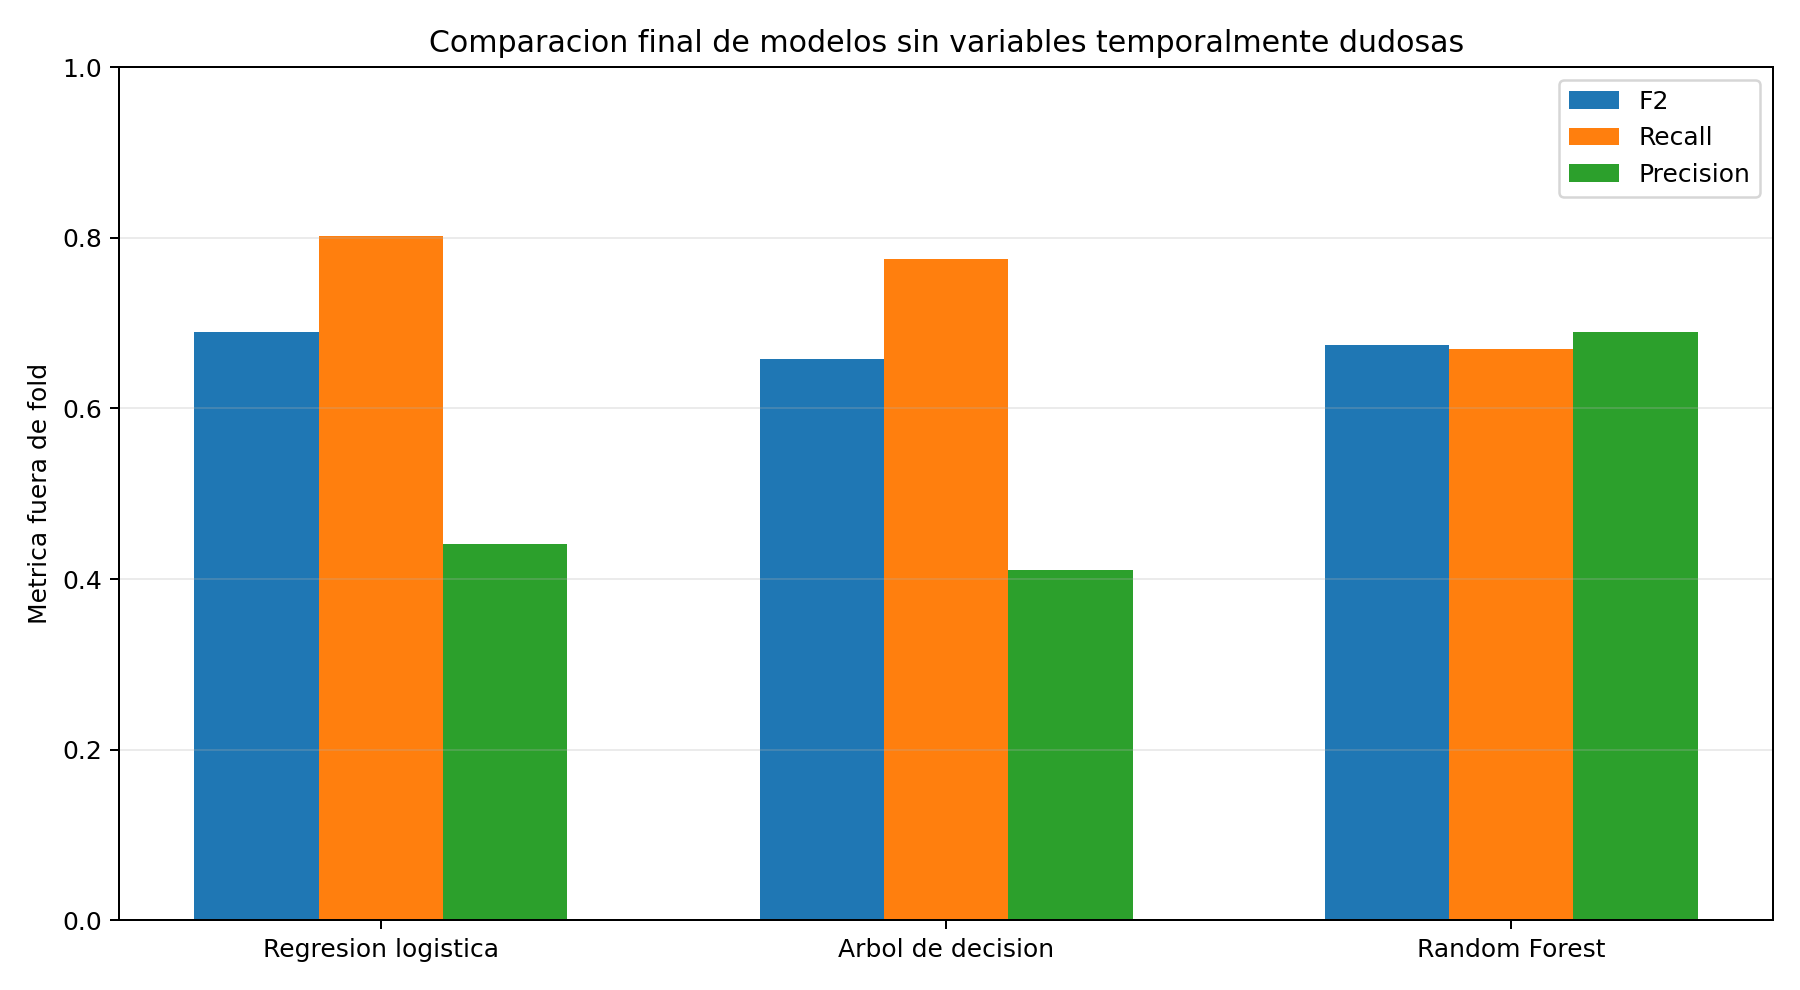

,scenario,f2,recall,precision,pr_auc,roc_auc
0,Completo,0.754,0.753,0.760,0.831,0.957
1,Sin Complain,0.700,0.698,0.711,0.787,0.944
2,Sin DaySinceLastOrder,0.742,0.738,0.758,0.816,0.953
3,Conservador: sin ambas,0.674,0.670,0.689,0.776,0.938


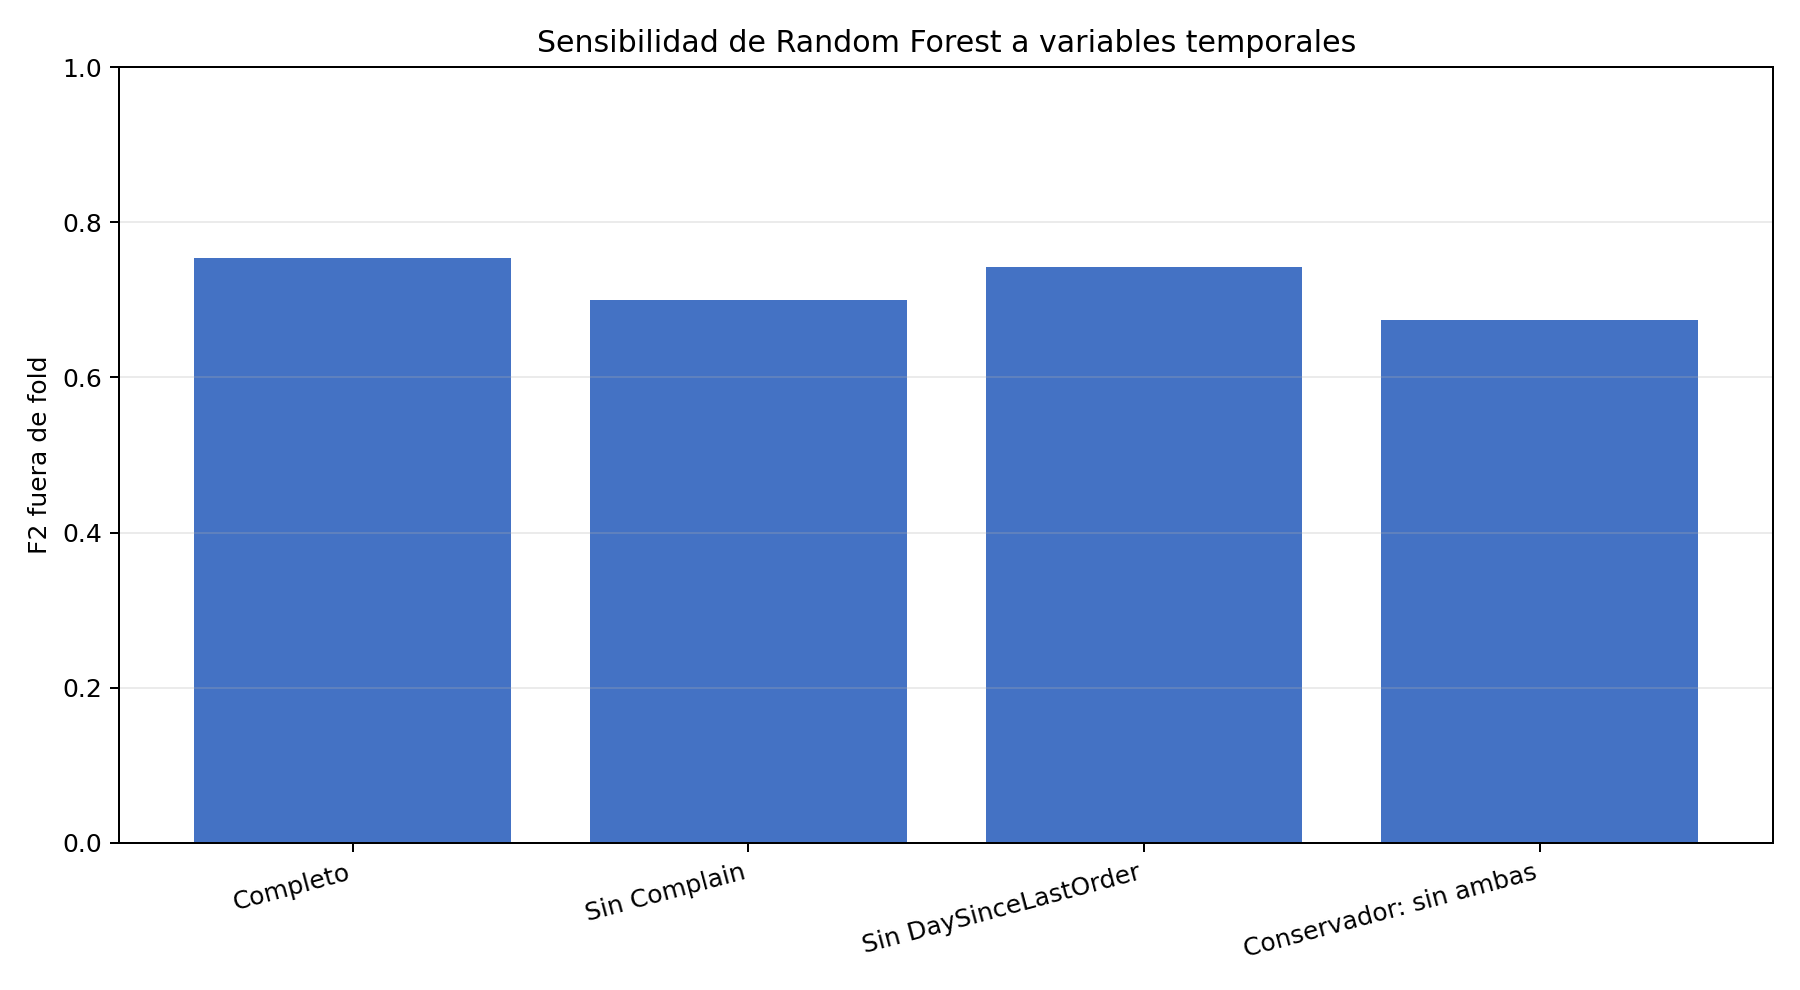

In [22]:

from IPython.display import Image, display

model_comparison = pd.DataFrame(
    final_results["model_comparison_oof_threshold_050"]
)[["model", "f2", "recall", "precision", "pr_auc", "roc_auc", "contacts"]]

temporal_sensitivity = pd.DataFrame(
    final_results["temporal_sensitivity_rf_threshold_050"]
)[["scenario", "f2", "recall", "precision", "pr_auc", "roc_auc"]]

display(model_comparison.round(3))
display(Image(filename="reports/figures/final_model_comparison_cv.png"))
display(temporal_sensitivity.round(3))
display(Image(filename="reports/figures/temporal_sensitivity_f2.png"))



## 15. Evaluacion final en test

El umbral se eligio exclusivamente con probabilidades fuera de fold de train. Despues de congelar modelo, variables y umbral, test se utilizo para una unica evaluacion final.


,threshold,f2,recall,precision,f1,pr_auc,roc_auc,accuracy,contacts,tp,fp,fn,tn
0,0.410,0.665,0.837,0.365,0.508,0.577,0.857,0.733,422,154,268,30,664


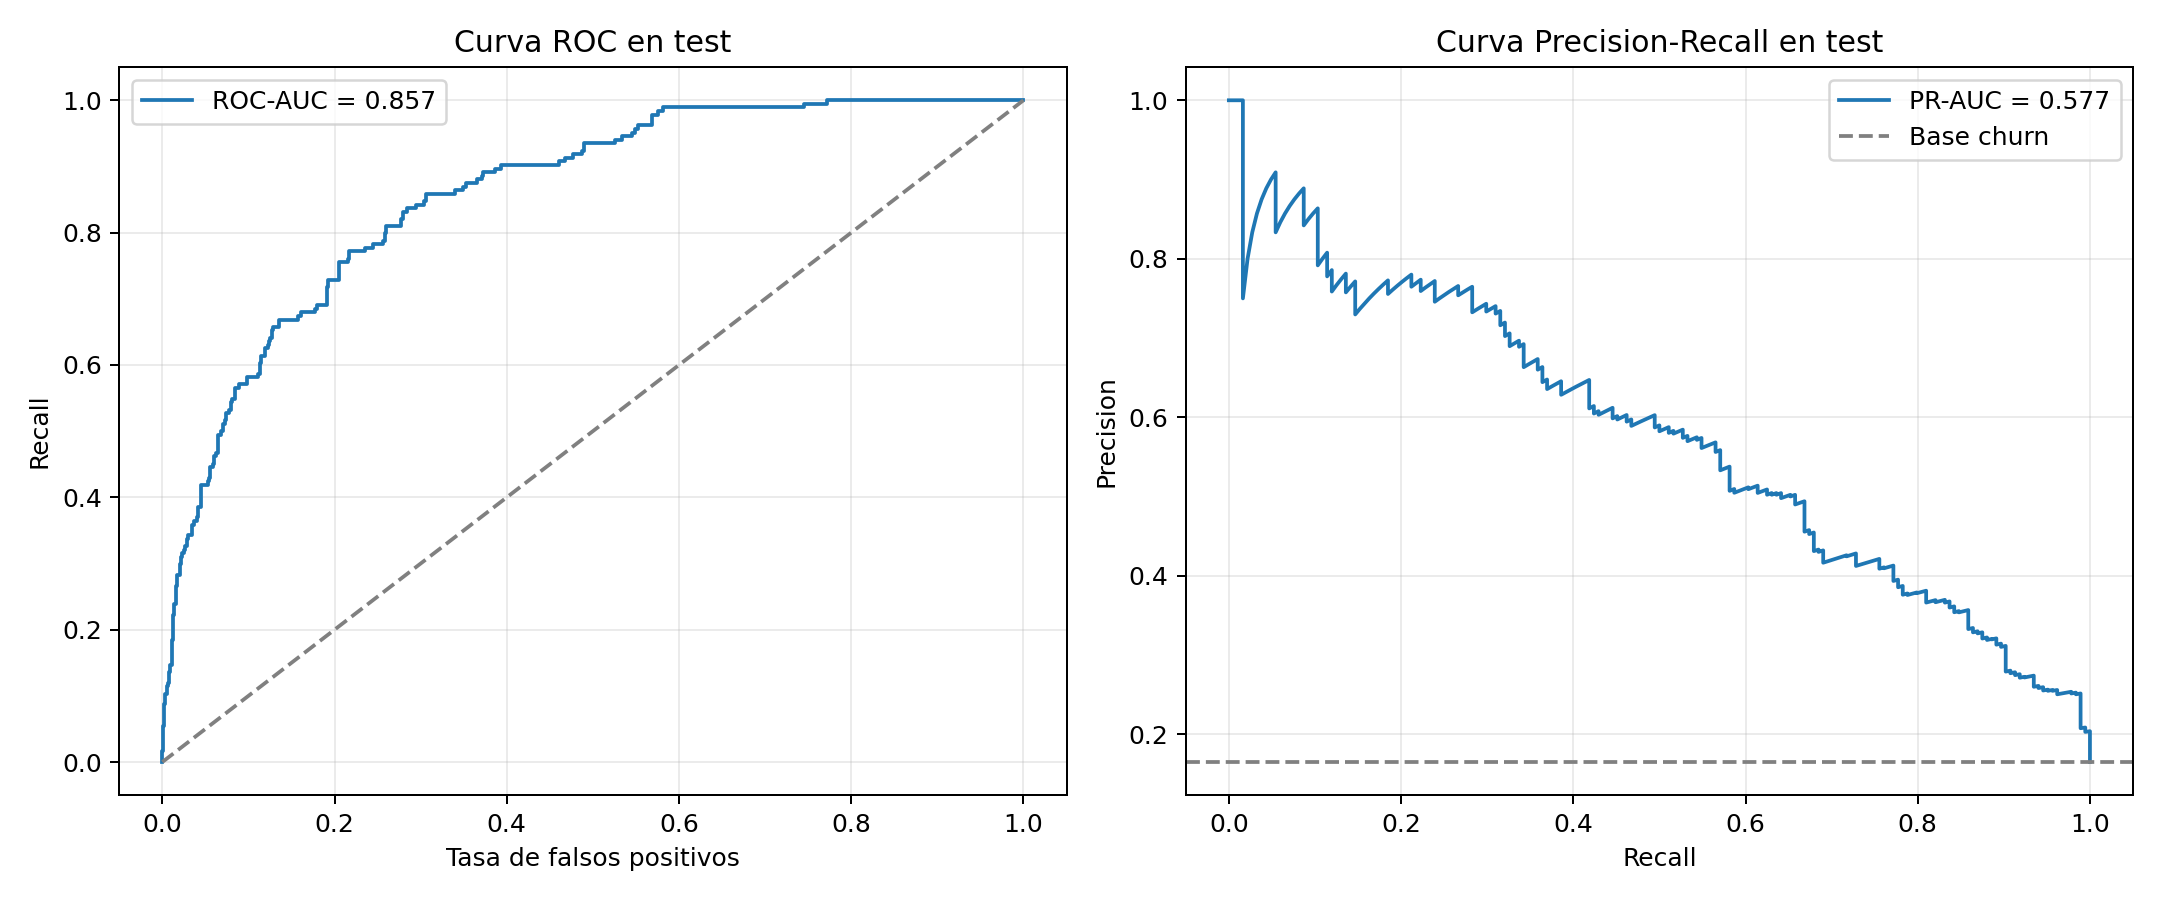

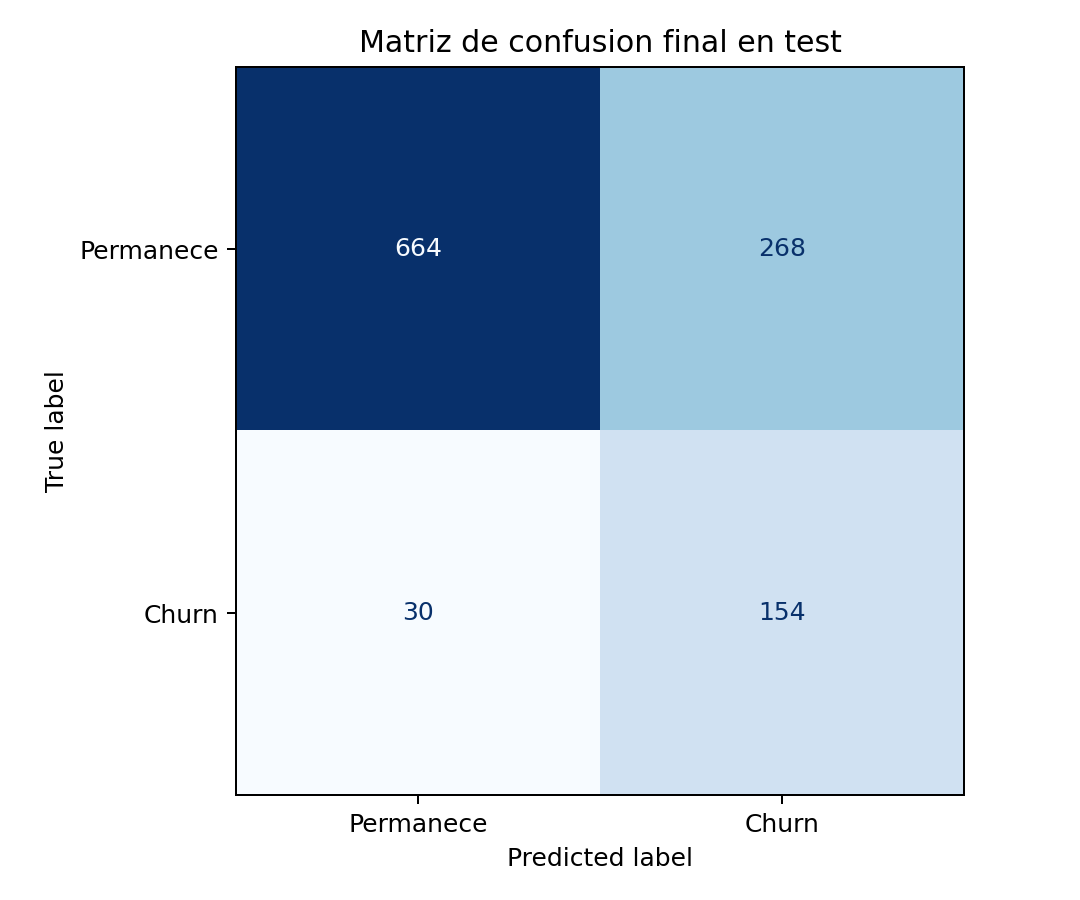

In [23]:

test_metrics = pd.DataFrame([final_results["final_test_metrics"]])
display(test_metrics.round(3))
display(Image(filename="reports/figures/final_test_roc_pr.png"))
display(Image(filename="reports/figures/final_test_confusion_matrix.png"))



## 16. Interpretabilidad: importancia y SHAP

- La importancia por permutacion mide cuanto cae F2 cuando se desordena una variable.
- SHAP global resume que variables modifican mas las predicciones.
- SHAP local explica por que dos clientes concretos recibieron riesgo alto o bajo.

Estas tecnicas explican el comportamiento del modelo, no relaciones causales.


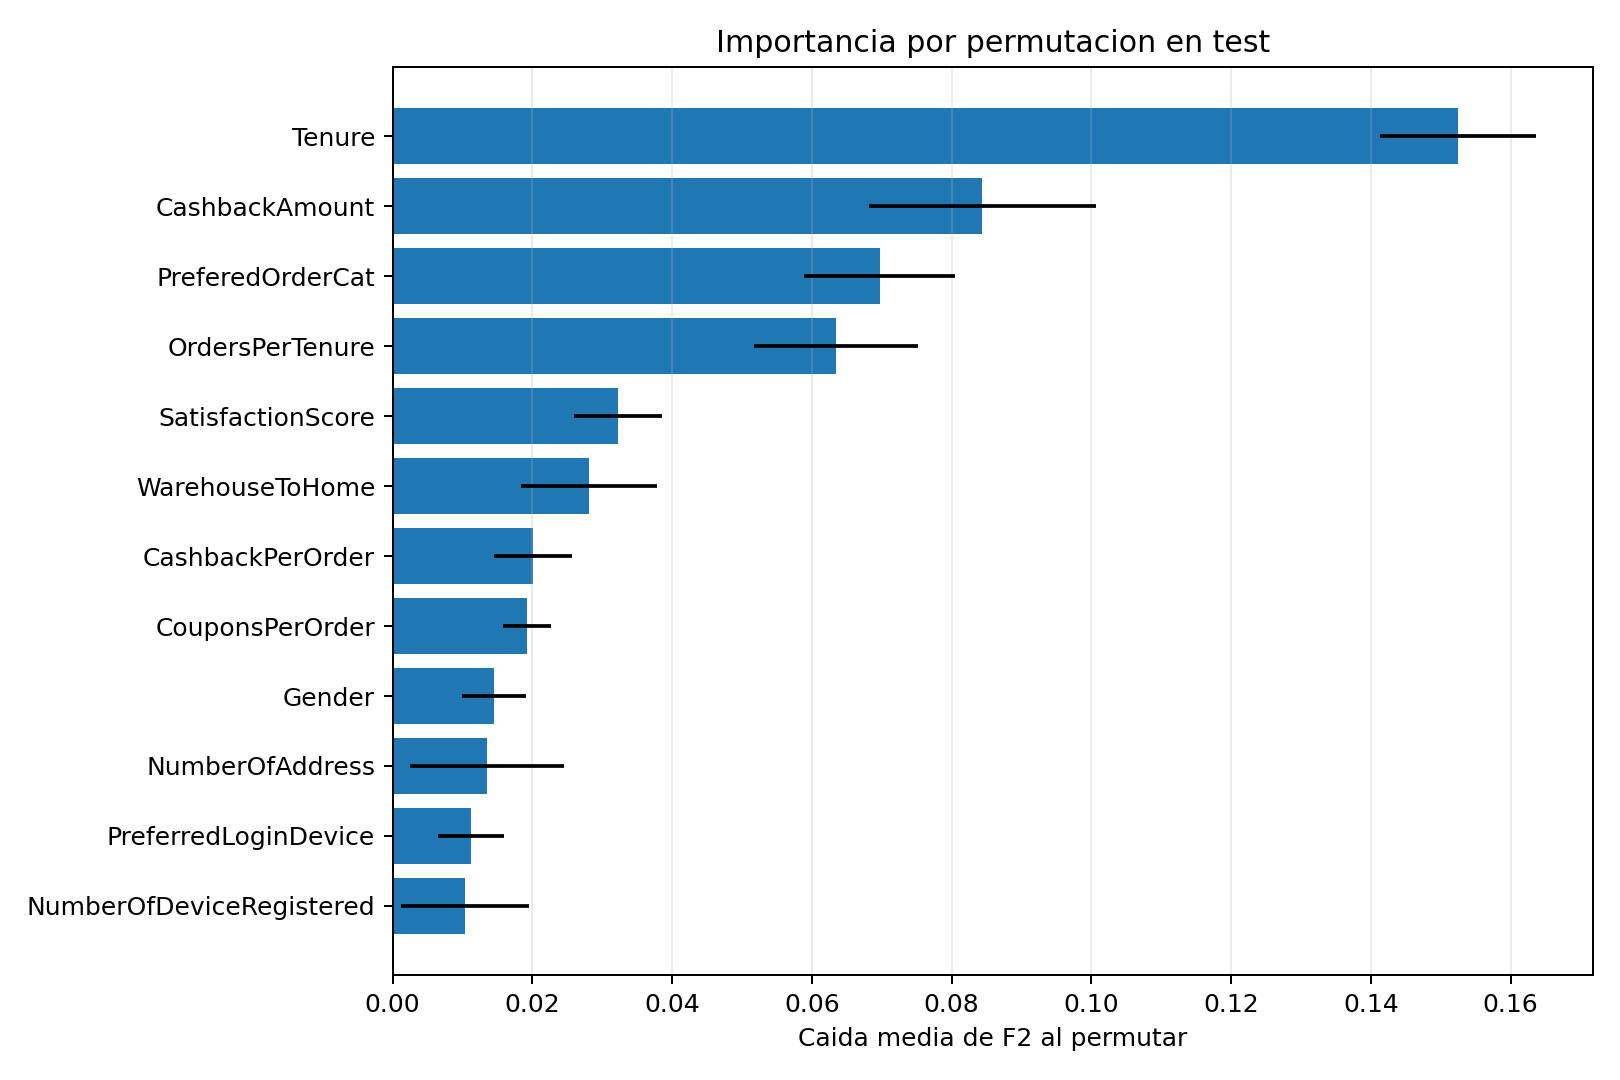

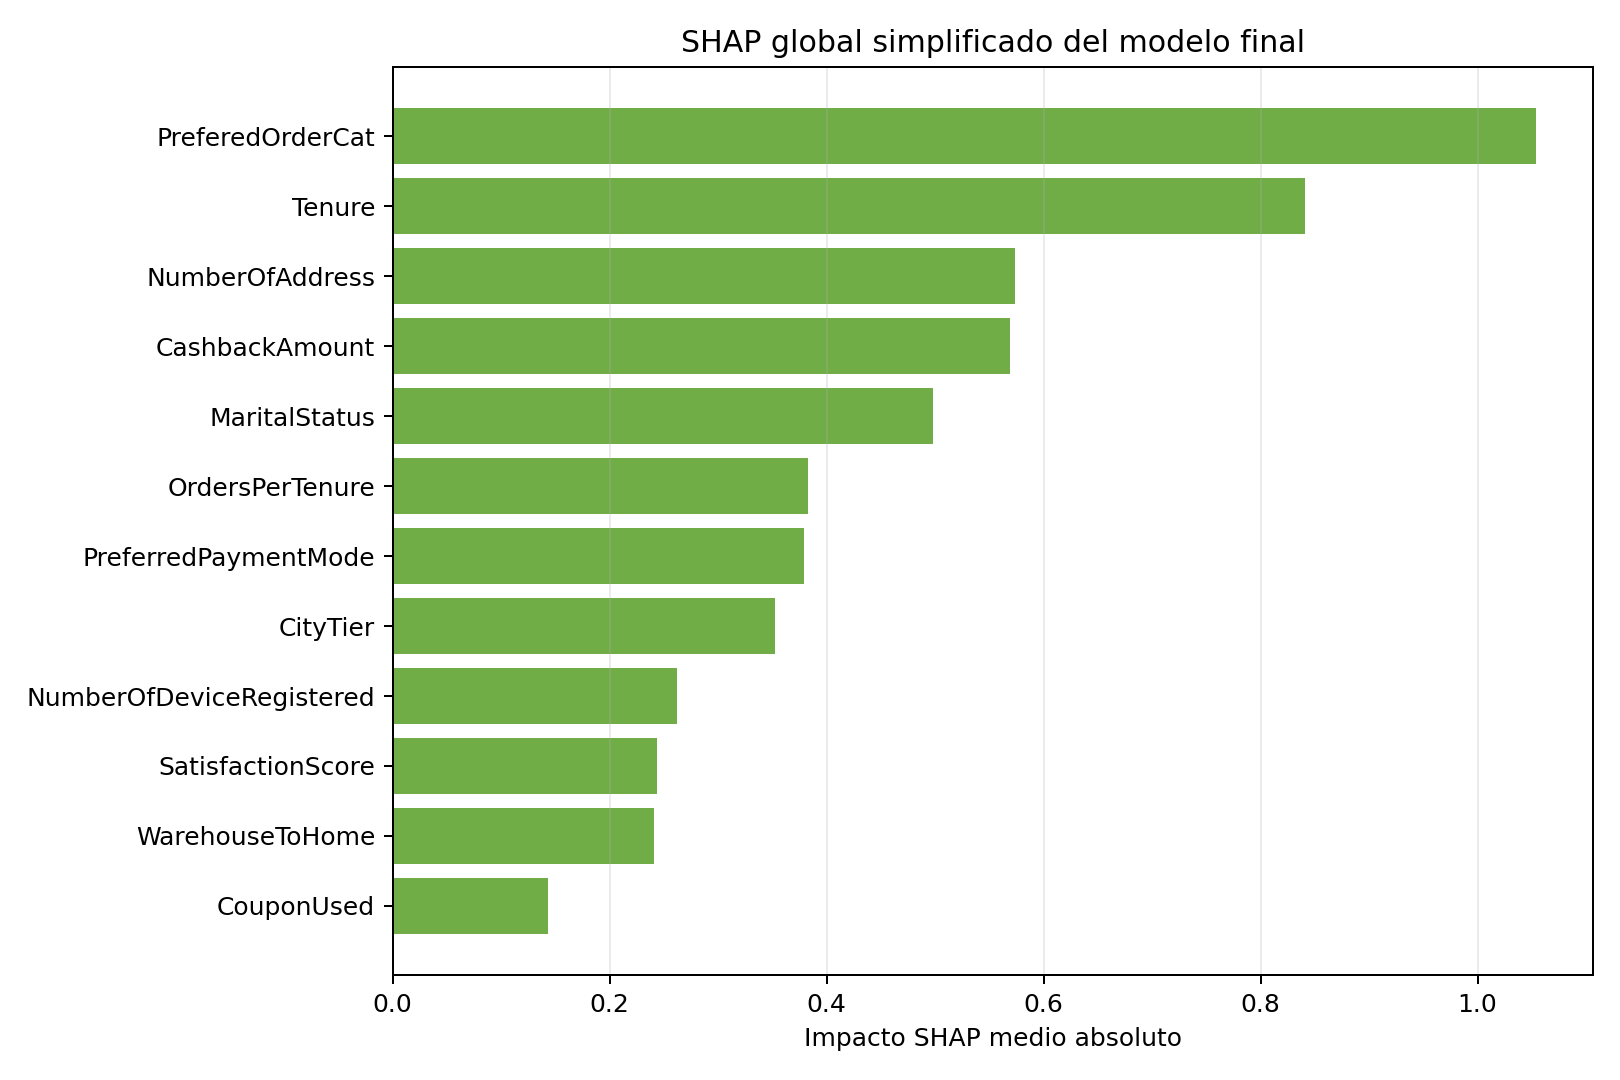

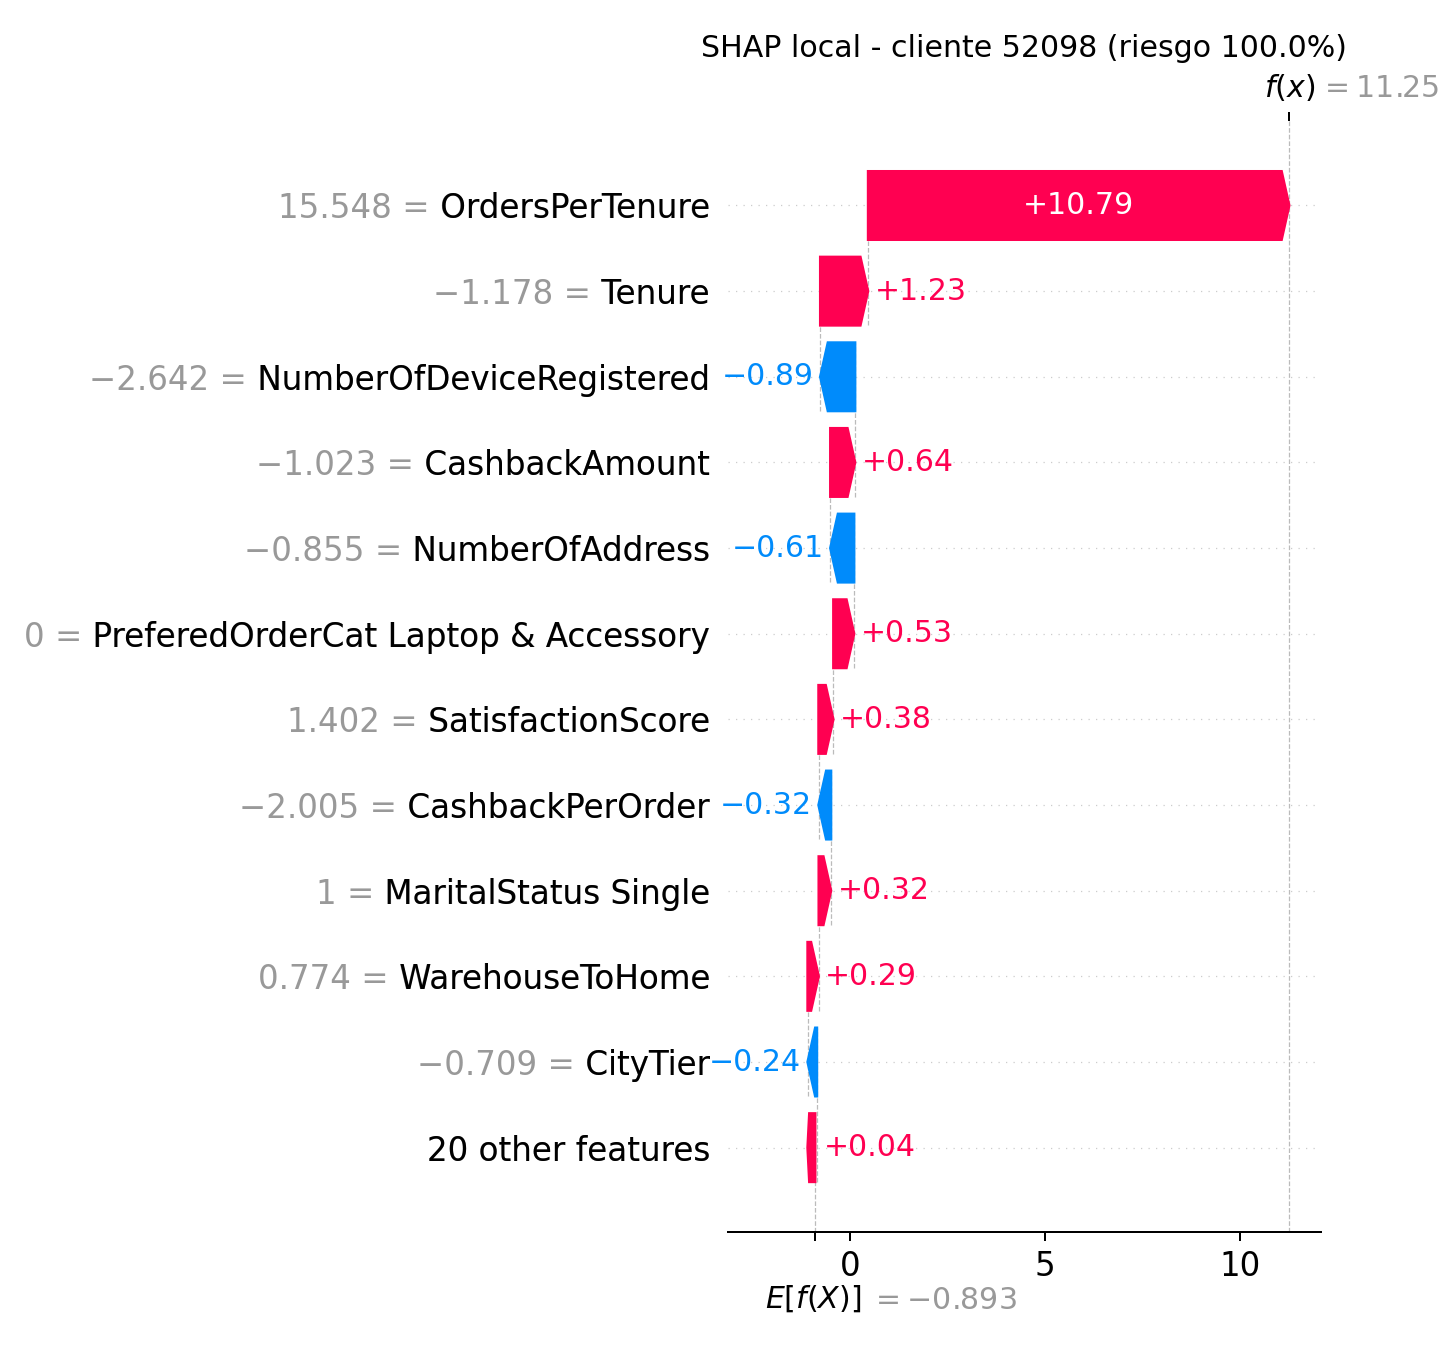

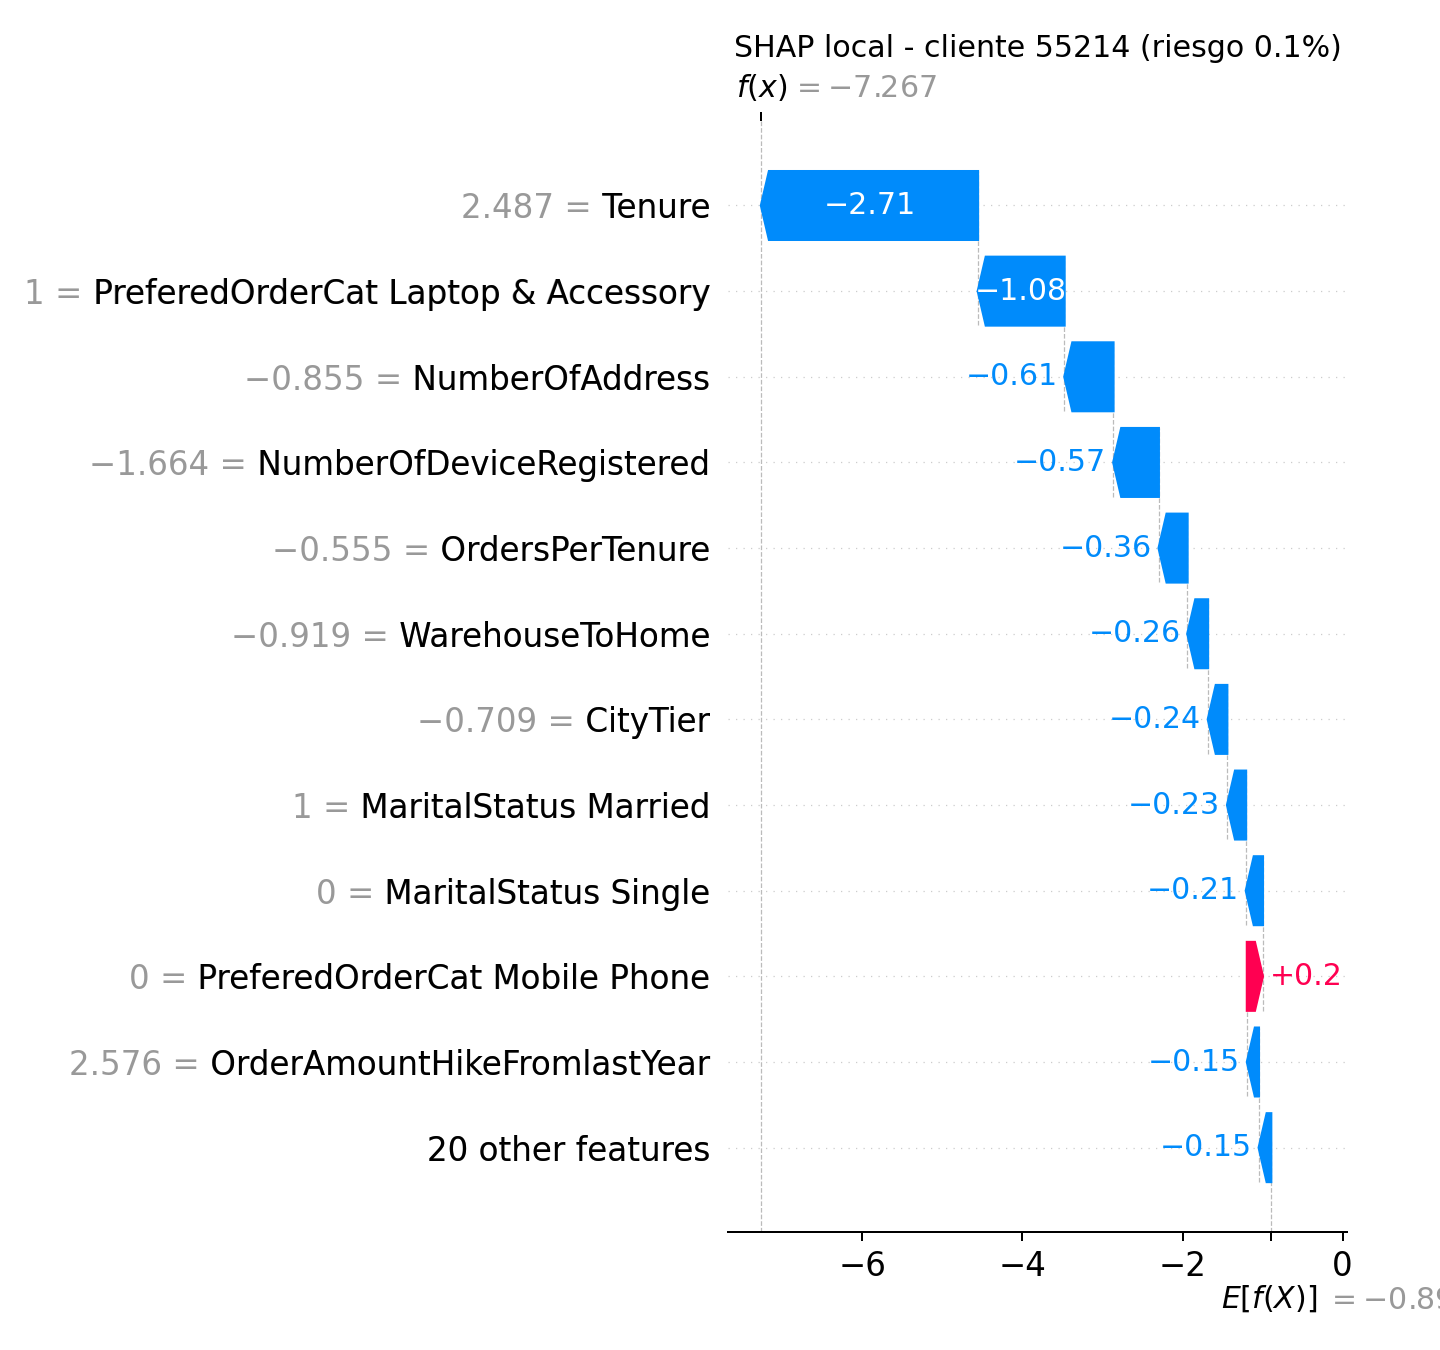

In [24]:

display(Image(filename="reports/figures/final_feature_importance.png"))
display(Image(filename="reports/figures/final_shap_global.png"))
display(Image(filename="reports/figures/final_shap_local_high_risk.png"))
display(Image(filename="reports/figures/final_shap_local_low_risk.png"))
